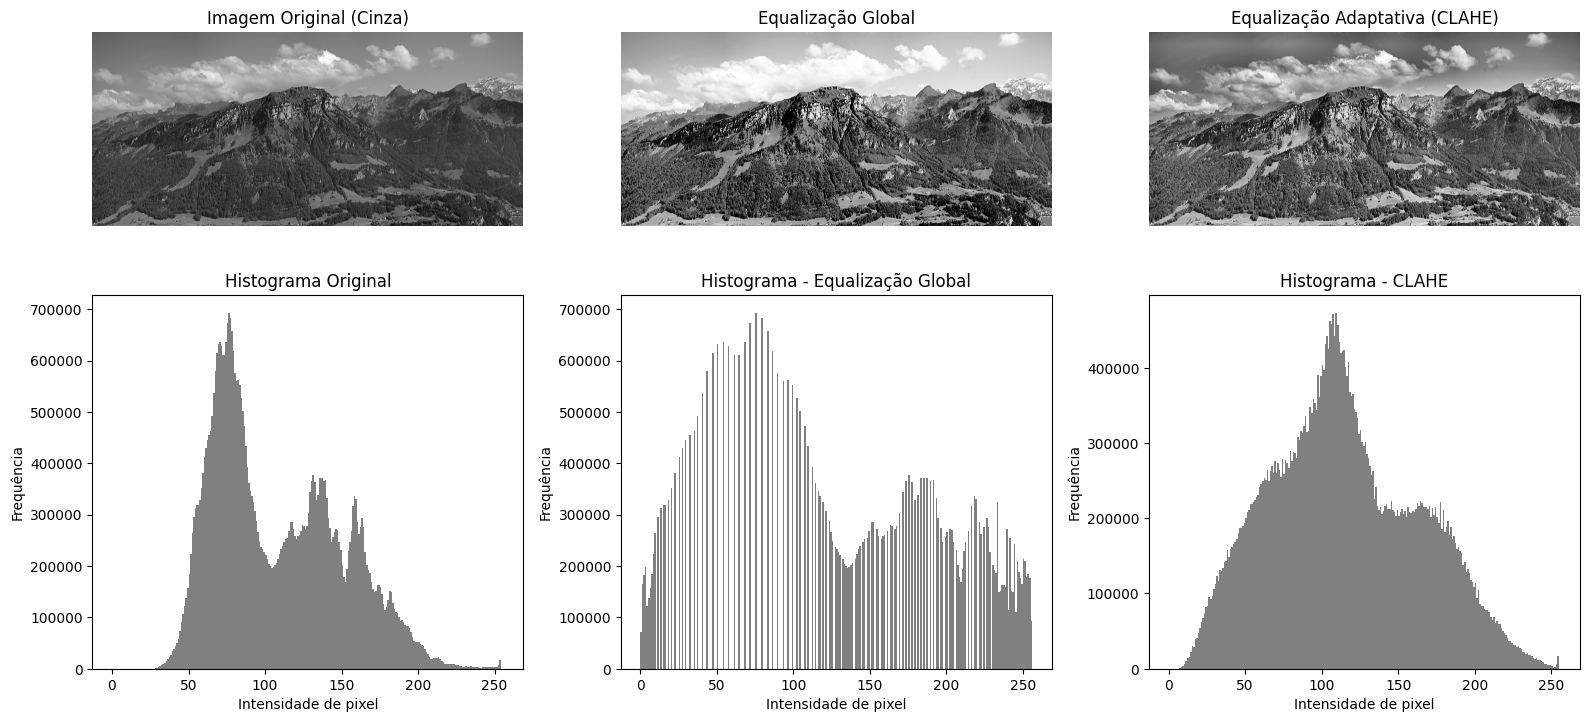

In [4]:
# ===============================
# Revisão: Melhoramento de Imagens com Equalização Global e CLAHE
# ===============================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import Request, urlopen

# -------------------------------
# 1. Ler imagem a partir de uma URL (com cabeçalho User-Agent)
# -------------------------------
url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/Fronalpstock_big.jpg"

try:
    # Adiciona um cabeçalho para evitar bloqueios 403
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urlopen(req)
    image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
except Exception as e:
    print(f"Erro ao carregar imagem: {e}")
    # Usa uma imagem alternativa em caso de erro
    url_alt = "https://images.unsplash.com/photo-1501785888041-af3ef285b470?w=800"
    req = Request(url_alt, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urlopen(req)
    image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# Converte para RGB para exibir corretamente no matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# -------------------------------
# 2. Converter para escala de cinza
# -------------------------------
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# -------------------------------
# 3. Equalização global e adaptativa
# -------------------------------
eq_global = cv2.equalizeHist(img_gray)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
eq_clahe = clahe.apply(img_gray)

# -------------------------------
# 4. Função auxiliar para histograma
# -------------------------------
def show_histogram(image, title):
    plt.hist(image.ravel(), bins=256, range=[0,256], color='gray')
    plt.title(title)
    plt.xlabel('Intensidade de pixel')
    plt.ylabel('Frequência')

# -------------------------------
# 5. Exibir resultados
# -------------------------------
plt.figure(figsize=(16,8))

plt.subplot(2,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Imagem Original (Cinza)")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(eq_global, cmap='gray')
plt.title("Equalização Global")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(eq_clahe, cmap='gray')
plt.title("Equalização Adaptativa (CLAHE)")
plt.axis("off")

plt.subplot(2,3,4)
show_histogram(img_gray, "Histograma Original")

plt.subplot(2,3,5)
show_histogram(eq_global, "Histograma - Equalização Global")

plt.subplot(2,3,6)
show_histogram(eq_clahe, "Histograma - CLAHE")

plt.tight_layout()
plt.show()


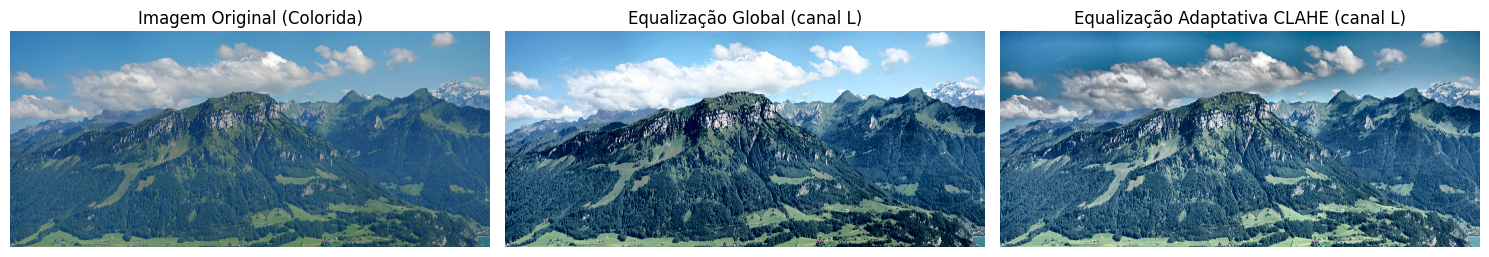

In [8]:
# ===============================
# Revisão: Melhoramento de Imagens Coloridas com CLAHE
# ===============================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import Request, urlopen

# -------------------------------
# 1. Ler imagem a partir de uma URL (com cabeçalho User-Agent)
# -------------------------------
url = "https://upload.wikimedia.org/wikipedia/commons/3/3f/Fronalpstock_big.jpg"

try:
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urlopen(req)
    image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
except Exception as e:
    print(f"Erro ao carregar imagem: {e}")
    url_alt = "https://images.unsplash.com/photo-1501785888041-af3ef285b470?w=800"
    req = Request(url_alt, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urlopen(req)
    image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# Converte para RGB (para exibir no matplotlib)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# -------------------------------
# 2. Converter de RGB para LAB
# -------------------------------
# LAB separa brilho (L) e cores (A, B)
img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
L, A, B = cv2.split(img_lab)

# -------------------------------
# 3. Equalização global e CLAHE no canal L
# -------------------------------
# Equalização global
L_eq = cv2.equalizeHist(L)

# Equalização adaptativa (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
L_clahe = clahe.apply(L)

# -------------------------------
# 4. Recombinar canais e converter de volta para RGB
# -------------------------------
# Global
img_lab_eq = cv2.merge((L_eq, A, B))
img_rgb_eq = cv2.cvtColor(img_lab_eq, cv2.COLOR_LAB2RGB)

# CLAHE
img_lab_clahe = cv2.merge((L_clahe, A, B))
img_rgb_clahe = cv2.cvtColor(img_lab_clahe, cv2.COLOR_LAB2RGB)

# -------------------------------
# 5. Exibir imagens lado a lado
# -------------------------------
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Imagem Original (Colorida)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_rgb_eq)
plt.title("Equalização Global (canal L)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_rgb_clahe)
plt.title("Equalização Adaptativa CLAHE (canal L)")
plt.axis("off")

plt.tight_layout()
plt.show()


